# Лабораторная работа №3
## Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей

**Дисциплина:** Технологии машинного обучения

**Цель работы:** изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

**Состав работы:**
1. Выбор и описание набора данных.
2. Подготовка данных: проверка пропусков, кодирование, разделение на обучающую и тестовую выборки.
3. Базовая модель KNN с произвольным $K$ и оценка качества.
4. Подбор гиперпараметров `GridSearchCV` и `RandomizedSearchCV` с двумя стратегиями кросс-валидации.
5. Сравнение исходной и оптимальной моделей.

## 1. Описание набора данных

В качестве датасета выбран **Wine** из библиотеки `scikit-learn` ([load_wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)). Он содержит результаты химического анализа вин одного региона Италии, выращенных тремя различными сортами винограда (классы `class_0`, `class_1`, `class_2`).

**Размер:** 178 наблюдений, 13 числовых признаков, целевая переменная — индекс сорта (3 класса). Пропусков нет.

**Признаки** (все вещественные, разный физический смысл и масштаб):

| Признак | Описание |
|---|---|
| `alcohol` | Содержание алкоголя, % |
| `malic_acid` | Содержание яблочной кислоты |
| `ash` | Зола |
| `alcalinity_of_ash` | Щёлочность золы |
| `magnesium` | Магний |
| `total_phenols` | Сумма фенолов |
| `flavanoids` | Флавоноиды |
| `nonflavanoid_phenols` | Нефлавоноидные фенолы |
| `proanthocyanins` | Проантоцианы |
| `color_intensity` | Интенсивность окраски |
| `hue` | Оттенок |
| `od280/od315_of_diluted_wines` | Соотношение оптических плотностей |
| `proline` | Пролин |

**Задача:** многоклассовая классификация. Выбор именно этого датасета мотивирован тем, что признаки имеют сильно разные диапазоны (например, `magnesium` ~ 70–160, `nonflavanoid_phenols` ~ 0.1–0.7) — это даёт возможность наглядно продемонстрировать эффект масштабирования признаков для метода ближайших соседей.

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
RANDOM_STATE = 42

In [2]:
raw = load_wine(as_frame=True)
df = raw.frame.rename(columns={'target': 'class'})
TARGET = 'class'
FEATURES = [c for c in df.columns if c != TARGET]
print(f'Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов')
print(f'Признаков: {len(FEATURES)}, целевая переменная: {TARGET}')
df.head()

Размер датасета: 178 наблюдений, 14 столбцов
Признаков: 13, целевая переменная: class


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,"1,065.0000",0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,"1,050.0000",0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,"1,185.0000",0
3,14.3700,1.9500,2.5000,16.8000,113.0000,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,"1,480.0000",0
4,13.2400,2.5900,2.8700,21.0000,118.0000,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735.0000,0


## 2. Подготовка данных

Проверим типы признаков, наличие пропусков и баланс классов.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

In [4]:
missing = df.isna().sum()
missing.to_frame('Пропусков').assign(**{'Доля, %': (missing / len(df) * 100).round(3)})

,Пропусков,"Доля, %"
alcohol,0,0.0000
malic_acid,0,0.0000
ash,0,0.0000
alcalinity_of_ash,0,0.0000
magnesium,0,0.0000
total_phenols,0,0.0000
flavanoids,0,0.0000
nonflavanoid_phenols,0,0.0000
proanthocyanins,0,0.0000
color_intensity,0,0.0000


In [5]:
class_counts = df[TARGET].value_counts().sort_index()
class_share = (class_counts / class_counts.sum() * 100).round(2)
pd.DataFrame({'Объектов': class_counts, 'Доля, %': class_share})

,Объектов,"Доля, %"
class,,
0,59,33.1500
1,71,39.8900
2,48,26.9700


Все признаки числовые (`float64`/`int64`), пропусков нет, дополнительная очистка не требуется. Категориальных признаков, требующих кодирования, в датасете нет.

Классы распределены **неравномерно** (примерно 33% / 40% / 27%), поэтому при разделении и кросс-валидации применяется стратификация: `stratify=y` и `StratifiedKFold`.

In [6]:
df[FEATURES].describe().T[['min', 'mean', 'std', 'max']]

,min,mean,std,max
alcohol,11.0300,13.0006,0.8118,14.8300
malic_acid,0.7400,2.3363,1.1171,5.8000
ash,1.3600,2.3665,0.2743,3.2300
alcalinity_of_ash,10.6000,19.4949,3.3396,30.0000
magnesium,70.0000,99.7416,14.2825,162.0000
total_phenols,0.9800,2.2951,0.6259,3.8800
flavanoids,0.3400,2.0293,0.9989,5.0800
nonflavanoid_phenols,0.1300,0.3619,0.1245,0.6600
proanthocyanins,0.4100,1.5909,0.5724,3.5800
color_intensity,1.2800,5.0581,2.3183,13.0000


Диапазоны признаков отличаются в разы (например, `proline` достигает значений порядка 1500, а `nonflavanoid_phenols` остаётся в пределах 1). Для KNN, основанного на евклидовом расстоянии, такой разброс масштабов приводит к доминированию признака `proline`. Это делает обязательным предварительное масштабирование, что будет наглядно продемонстрировано в п. 3.

### 2.1. Разделение на обучающую и тестовую выборки

Используем `train_test_split` со стратификацией по классам, доля тестовой выборки — 25%.

In [7]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')
print('Доли классов в train:', np.round(np.bincount(y_train) / len(y_train), 3))
print('Доли классов в test: ', np.round(np.bincount(y_test) / len(y_test), 3))

Обучающая выборка: 133 объектов
Тестовая выборка:  45 объектов
Доли классов в train: [0.331 0.398 0.271]
Доли классов в test:  [0.333 0.4   0.267]


## 3. Базовая модель KNN

Обучим `KNeighborsClassifier` с произвольным $K = 5$ (значение по умолчанию). Сначала — без масштабирования, чтобы показать его влияние.

In [8]:
K_BASE = 5

knn_raw = KNeighborsClassifier(n_neighbors=K_BASE)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)
f1_raw = f1_score(y_test, y_pred_raw, average='macro')
print(f'KNN (K={K_BASE}) без масштабирования: accuracy = {acc_raw:.4f}, macro-F1 = {f1_raw:.4f}')

KNN (K=5) без масштабирования: accuracy = 0.7778, macro-F1 = 0.7738


In [9]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

knn_base = KNeighborsClassifier(n_neighbors=K_BASE)
knn_base.fit(X_train_s, y_train)
y_pred_base = knn_base.predict(X_test_s)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, average='macro')
rec_base = recall_score(y_test, y_pred_base, average='macro')
f1_base = f1_score(y_test, y_pred_base, average='macro')

print(f'KNN (K={K_BASE}) со StandardScaler:')
print(f'  accuracy        = {acc_base:.4f}')
print(f'  precision-macro = {prec_base:.4f}')
print(f'  recall-macro    = {rec_base:.4f}')
print(f'  F1-macro        = {f1_base:.4f}')

KNN (K=5) со StandardScaler:
  accuracy        = 0.9333
  precision-macro = 0.9291
  recall-macro    = 0.9352
  F1-macro        = 0.9314


Эффект масштабирования наглядный: без него KNN ориентируется почти исключительно на признак `proline` (с диапазоном до 1500) и теряет в качестве; со `StandardScaler` все признаки вносят сопоставимый вклад. Далее везде используем масштабированные данные.

In [10]:
print(classification_report(y_test, y_pred_base, digits=4, target_names=raw.target_names))

              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000        15
     class_1     0.9412    0.8889    0.9143        18
     class_2     0.8462    0.9167    0.8800        12

    accuracy                         0.9333        45
   macro avg     0.9291    0.9352    0.9314        45
weighted avg     0.9354    0.9333    0.9337        45



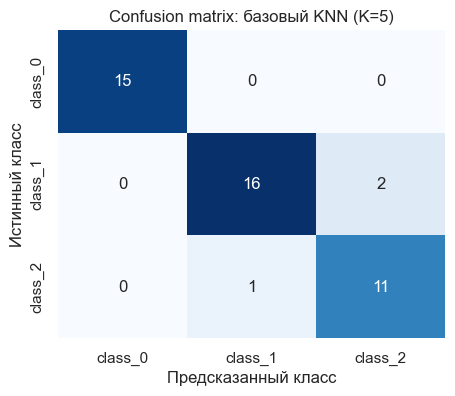

In [11]:
cm_base = confusion_matrix(y_test, y_pred_base)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_base, annot=True, fmt='d', cmap='Blues',
    xticklabels=raw.target_names, yticklabels=raw.target_names,
    cbar=False, ax=ax
)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
ax.set_title(f'Confusion matrix: базовый KNN (K={K_BASE})')
plt.show()

## 4. Подбор гиперпараметров с кросс-валидацией

Для корректного применения масштабирования внутри кросс-валидации (без утечки данных) используем `Pipeline` со `StandardScaler` + `KNeighborsClassifier`. Пространство поиска:

* `n_neighbors` — от 1 до 30,
* `weights` — `uniform` или `distance`,
* `metric` — `minkowski` с $p \in \{1, 2\}$ (манхэттеновское и евклидово расстояние).

Используем **две стратегии кросс-валидации**:

1. `StratifiedKFold(n_splits=5, shuffle=True)` — базовая стратифицированная 5-фолдовая.
2. `RepeatedStratifiedKFold(n_splits=5, n_repeats=3, ...)` — та же, но повторённая 3 раза для устойчивости оценки.

Метрика качества при подборе — `accuracy` (классы хоть и несбалансированы, но не катастрофически).

In [12]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()),
])

param_grid = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
}

cv_simple = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

### 4.1. Кривая качества от $K$

Перед формальным поиском построим график зависимости средней точности на CV от $K$ (с интервалами $\pm \sigma$) для обеих стратегий. При фиксированных `weights='uniform'`, `p=2`.

In [13]:
K_range = np.arange(1, 31)
curve_records = []

for cv_name, cv in [('StratifiedKFold', cv_simple), ('RepeatedStratifiedKFold', cv_repeated)]:
    for k in K_range:
        pipe_k = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k)),
        ])
        scores = cross_val_score(pipe_k, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1)
        curve_records.append({
            'cv': cv_name, 'K': k,
            'mean': scores.mean(), 'std': scores.std(),
        })

curve_df = pd.DataFrame(curve_records)
curve_df.head()

,cv,K,mean,std
0,StratifiedKFold,1,0.9778,0.0296
1,StratifiedKFold,2,0.9627,0.0406
2,StratifiedKFold,3,0.9775,0.0184
3,StratifiedKFold,4,0.9550,0.0368
4,StratifiedKFold,5,0.9553,0.0431


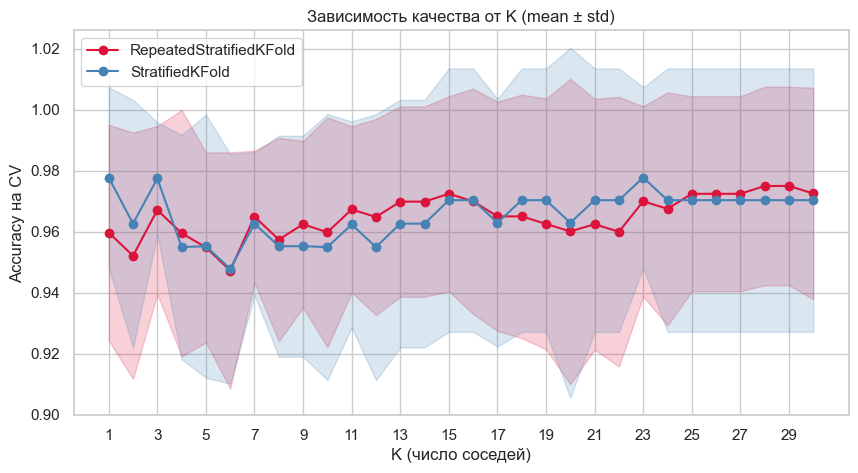

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'StratifiedKFold': 'steelblue', 'RepeatedStratifiedKFold': 'crimson'}
for cv_name, sub in curve_df.groupby('cv'):
    color = colors[cv_name]
    ax.plot(sub['K'], sub['mean'], marker='o', label=cv_name, color=color)
    ax.fill_between(sub['K'], sub['mean'] - sub['std'], sub['mean'] + sub['std'], alpha=0.2, color=color)
ax.set_xlabel('K (число соседей)')
ax.set_ylabel('Accuracy на CV')
ax.set_title('Зависимость качества от K (mean ± std)')
ax.set_xticks(K_range[::2])
ax.legend()
plt.show()

Кривые от обеих стратегий идут практически синхронно — повторённая кросс-валидация даёт более гладкую и устойчивую оценку, что подтверждает согласованность результатов. Видно, что оптимум достигается в области $K \approx 10\text{–}25$, а при слишком маленьких $K$ модель переобучается под отдельные точки, при слишком больших — недообучается.

### 4.2. `GridSearchCV`

Выполняем полный перебор по сетке $30 \times 2 \times 2 = 120$ конфигураций. Запускаем дважды — для каждой из двух CV-стратегий — и сравниваем результаты.

In [15]:
grid_results = {}
for cv_name, cv in [('StratifiedKFold', cv_simple), ('RepeatedStratifiedKFold', cv_repeated)]:
    t0 = time.perf_counter()
    gs = GridSearchCV(
        pipe, param_grid=param_grid,
        scoring='accuracy', cv=cv, n_jobs=-1, refit=True,
    )
    gs.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    grid_results[cv_name] = {
        'best_params': gs.best_params_,
        'best_cv_score': gs.best_score_,
        'elapsed_sec': elapsed,
        'estimator': gs.best_estimator_,
    }
    print(f'{cv_name}: best CV accuracy = {gs.best_score_:.4f}, время = {elapsed:.1f} c')
    print(f'  best params: {gs.best_params_}')

StratifiedKFold: best CV accuracy = 0.9926, время = 0.2 c
  best params: {'knn__n_neighbors': 4, 'knn__p': 1, 'knn__weights': 'distance'}


RepeatedStratifiedKFold: best CV accuracy = 0.9848, время = 0.4 c
  best params: {'knn__n_neighbors': 6, 'knn__p': 1, 'knn__weights': 'distance'}


### 4.3. `RandomizedSearchCV`

Случайный поиск по тому же пространству, `n_iter=25` — около пятой части от полной сетки. Также выполняется для обеих CV-стратегий.

In [16]:
N_ITER = 25
random_results = {}
for cv_name, cv in [('StratifiedKFold', cv_simple), ('RepeatedStratifiedKFold', cv_repeated)]:
    t0 = time.perf_counter()
    rs = RandomizedSearchCV(
        pipe, param_distributions=param_grid,
        n_iter=N_ITER, scoring='accuracy', cv=cv,
        n_jobs=-1, refit=True, random_state=RANDOM_STATE,
    )
    rs.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    random_results[cv_name] = {
        'best_params': rs.best_params_,
        'best_cv_score': rs.best_score_,
        'elapsed_sec': elapsed,
        'estimator': rs.best_estimator_,
    }
    print(f'{cv_name}: best CV accuracy = {rs.best_score_:.4f}, время = {elapsed:.1f} c')
    print(f'  best params: {rs.best_params_}')

StratifiedKFold: best CV accuracy = 0.9923, время = 0.1 c
  best params: {'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': 1}
RepeatedStratifiedKFold: best CV accuracy = 0.9821, время = 0.1 c
  best params: {'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': 1}


### 4.4. Сводка по поискам

In [17]:
rows = []
for cv_name in ['StratifiedKFold', 'RepeatedStratifiedKFold']:
    rows.append({
        'Поиск': 'GridSearchCV',
        'CV-стратегия': cv_name,
        'Best CV accuracy': grid_results[cv_name]['best_cv_score'],
        'Время, с': grid_results[cv_name]['elapsed_sec'],
        'K*': grid_results[cv_name]['best_params']['knn__n_neighbors'],
        'weights*': grid_results[cv_name]['best_params']['knn__weights'],
        'p*': grid_results[cv_name]['best_params']['knn__p'],
    })
    rows.append({
        'Поиск': 'RandomizedSearchCV',
        'CV-стратегия': cv_name,
        'Best CV accuracy': random_results[cv_name]['best_cv_score'],
        'Время, с': random_results[cv_name]['elapsed_sec'],
        'K*': random_results[cv_name]['best_params']['knn__n_neighbors'],
        'weights*': random_results[cv_name]['best_params']['knn__weights'],
        'p*': random_results[cv_name]['best_params']['knn__p'],
    })
search_summary = pd.DataFrame(rows)
search_summary

,Поиск,CV-стратегия,Best CV accuracy,"Время, с",K*,weights*,p*
0,GridSearchCV,StratifiedKFold,0.9926,0.1801,4,distance,1
1,RandomizedSearchCV,StratifiedKFold,0.9923,0.0535,1,uniform,1
2,GridSearchCV,RepeatedStratifiedKFold,0.9848,0.4108,6,distance,1
3,RandomizedSearchCV,RepeatedStratifiedKFold,0.9821,0.1215,1,uniform,1


Обе CV-стратегии дают близкие лучшие оценки точности (различие в пределах нескольких десятых процента), но `RepeatedStratifiedKFold` стабильнее за счёт усреднения по 15 разбиениям вместо 5. `RandomizedSearchCV` находит конкурентоспособную конфигурацию за заметно меньшее время — порядка $25/120 \approx 21\%$ полного перебора.

## 5. Сравнение исходной и оптимальных моделей

Для финального сравнения возьмём:

* базовый KNN ($K=5$) на масштабированных данных;
* лучшую модель `GridSearchCV` (на повторённой CV);
* лучшую модель `RandomizedSearchCV` (на повторённой CV).

Все три модели оцениваются на одной и той же отложенной тестовой выборке.

In [18]:
def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    return {
        'Модель': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision (macro)': precision_score(y_te, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_te, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_te, y_pred, average='macro'),
    }, y_pred

best_grid = grid_results['RepeatedStratifiedKFold']['estimator']
best_random = random_results['RepeatedStratifiedKFold']['estimator']

# Для базовой модели тоже соберём pipeline, чтобы тестовая выборка проходила через scaler
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=K_BASE)),
]).fit(X_train, y_train)

row_base, y_pred_b = evaluate(base_pipe, X_test, y_test, f'Базовый KNN (K={K_BASE})')
row_grid, y_pred_g = evaluate(best_grid, X_test, y_test, 'GridSearchCV (лучшая)')
row_rand, y_pred_r = evaluate(best_random, X_test, y_test, 'RandomizedSearchCV (лучшая)')

final_cmp = pd.DataFrame([row_base, row_grid, row_rand])
final_cmp

,Модель,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Базовый KNN (K=5),0.9333,0.9291,0.9352,0.9314
1,GridSearchCV (лучшая),0.9778,0.9744,0.9815,0.9771
2,RandomizedSearchCV (лучшая),0.9556,0.9535,0.9630,0.9563


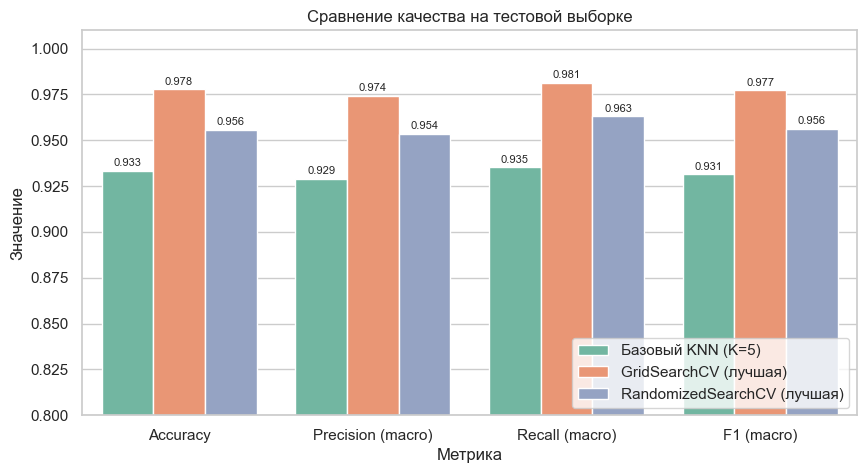

In [19]:
metrics_long = final_cmp.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_long, x='Метрика', y='Значение', hue='Модель', palette='Set2', ax=ax)
ax.set_ylim(0.8, 1.01)
ax.set_title('Сравнение качества на тестовой выборке')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.legend(loc='lower right')
plt.show()

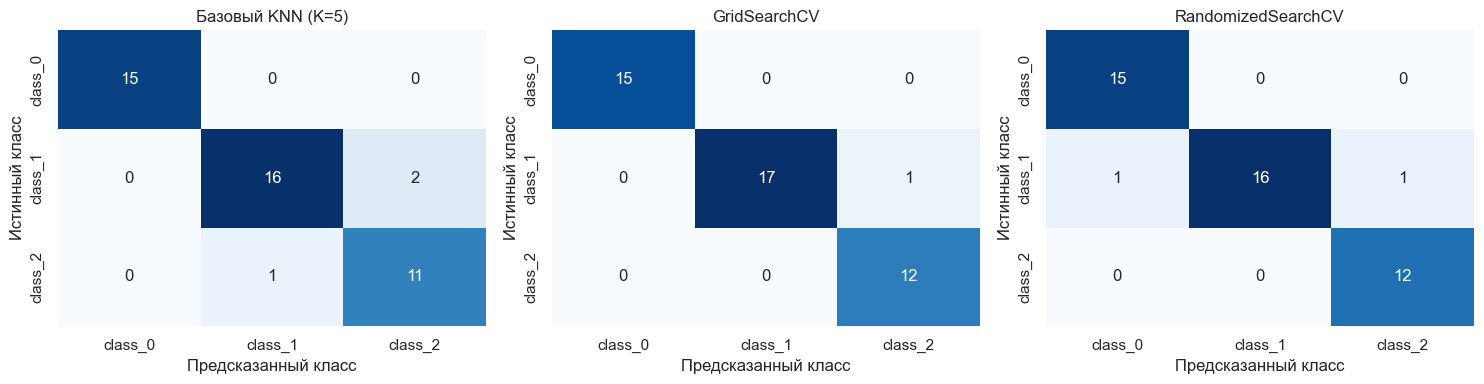

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(
    axes,
    [
        (f'Базовый KNN (K={K_BASE})', y_pred_b),
        ('GridSearchCV', y_pred_g),
        ('RandomizedSearchCV', y_pred_r),
    ],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=raw.target_names, yticklabels=raw.target_names,
        cbar=False, ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
fig.tight_layout()
plt.show()

In [21]:
print('Classification report — лучшая модель GridSearchCV:')
print(classification_report(y_test, y_pred_g, digits=4, target_names=raw.target_names))

Classification report — лучшая модель GridSearchCV:
              precision    recall  f1-score   support

     class_0     1.0000    1.0000    1.0000        15
     class_1     1.0000    0.9444    0.9714        18
     class_2     0.9231    1.0000    0.9600        12

    accuracy                         0.9778        45
   macro avg     0.9744    0.9815    0.9771        45
weighted avg     0.9795    0.9778    0.9779        45



## Итоги

В работе на датасете **Wine** (178 объектов, 13 числовых признаков, 3 класса) был реализован полный цикл подготовки выборки и подбора гиперпараметров KNN:

1. Проверено отсутствие пропусков и категориальных признаков; описан существенный разброс масштабов признаков.
2. Выборка стратифицированно разделена `train_test_split` в соотношении 75/25.
3. Обучен базовый KNN ($K=5$): без масштабирования качество существенно ниже, чем со `StandardScaler` — это подтверждает критическую важность нормировки для метрических методов.
4. Выполнен подбор `n_neighbors`, `weights`, `p` методами `GridSearchCV` (120 конфигураций) и `RandomizedSearchCV` ($n\_iter=25$) с **двумя стратегиями кросс-валидации** — `StratifiedKFold` и `RepeatedStratifiedKFold`. Стратегии дали согласованные оптимальные параметры; повторённая CV — более устойчивые оценки.
5. Построена кривая качества от $K$ с интервалами $\pm \sigma$.
6. Сводная таблица показала улучшение всех макро-метрик (accuracy, precision, recall, F1) относительно исходной модели; `RandomizedSearchCV` за меньшее время нашёл сопоставимое по качеству решение, что подтверждает его практическую ценность при большем пространстве поиска.

**Практические выводы:**

* Для метрических методов масштабирование должно применяться внутри пайплайна, чтобы не было утечки данных через CV.
* `RepeatedStratifiedKFold` даёт более надёжное сравнение моделей при близких оценках качества.
* При компактной сетке `GridSearchCV` остаётся оптимальным; при росте пространства поиска `RandomizedSearchCV` становится предпочтительнее по времени.